# Pattern Recognition 2 - Feature Space

**Objectives**

* Compute distances between objects in feature space
* Use PCA to perform reduce the dimensionality of the problem
* Implement face recognition using [Eigenfaces](http://en.wikipedia.org/wiki/Eigenface)

## Feature space distance

The `ocr_features.npy` file contains extracted features for each letter from the document used in the previous lab, and the `ocr_class.npy` file contains the character corresponding to these features.

The 18 features, extracted with the `regionprops` methods from `scikit-image` are, in order: 

> area, convex area, eccentricity, equivalent diameter, extent, filled area, intertia tensor eigenvalue 1, inertia tensor eigenvalue 2, major axis length, minor axis length, Hu moment 1, Hu moment 2, Hu moment 3, Hu moment 4, Hu moment 5, Hu moment 6, perimeter, solidity

* Create a method which computes the Euclidian distance, in feature space, between two objects.
* Check if the "nearest" object is of the same class.
* What can you do to improve this "distance-based" classification? 

In [1]:
import numpy as np

ocr_features = np.load('ocr_features.npy')
ocr_class = np.load('ocr_class.npy')

print(ocr_features.shape)
print(np.unique(ocr_class))

(2392, 18)
['0' '1' '4' '5' 'A' 'B' 'C' 'D' 'F' 'G' 'I' 'L' 'M' 'N' 'O' 'R' 'S' 'T'
 'W' 'a' 'b' 'c' 'd' 'e' 'f' 'g' 'h' 'i' 'k' 'l' 'm' 'n' 'o' 'p' 'q' 'r'
 's' 't' 'u' 'v' 'w' 'x' 'y' 'z']


In [2]:
# Euclidian distance between two objects in feature space
def euclidian_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

# For one object, find its nearest neighbour (ignoring itself)
i = 0
d = np.array([euclidian_distance(ocr_features[i], x) for x in ocr_features])
d[i] = np.inf
nearest = np.argmin(d)

print("object class :", ocr_class[i])
print("nearest class:", ocr_class[nearest])
print("same class ? :", ocr_class[i] == ocr_class[nearest])


# Nearest-neighbour classification accuracy over the whole dataset
def nn_accuracy(X):
    ok = 0
    for j in range(len(X)):
        dist = np.sqrt(((X - X[j]) ** 2).sum(axis=1))
        dist[j] = np.inf
        ok += ocr_class[np.argmin(dist)] == ocr_class[j]
    return ok / len(X)

print("\naccuracy (raw features):", nn_accuracy(ocr_features))

# Improvement: the 18 features have very different ranges (area ~ hundreds,
# Hu moments ~ 1e-3), so the distance is dominated by the large-scale features.
# Standardizing each feature (zero mean, unit variance) gives them equal weight.
ocr_std = (ocr_features - ocr_features.mean(axis=0)) / ocr_features.std(axis=0)
print("accuracy (standardized) :", nn_accuracy(ocr_std))

object class : i
nearest class: i
same class ? : True

accuracy (raw features): 0.899247491638796
accuracy (standardized) : 0.9544314381270903


## Eigenfaces

The `faces.npy` file contains a 3D matrix containing 2963 images, each with 170x200 pixels, encoded in 8-bit grayscale.

In [3]:
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
print("backend:", matplotlib.get_backend())   # doit afficher un backend "inline"

faces = np.load('faces.npy')
print(faces.shape, faces.dtype, faces.min(), faces.max())

backend: module://matplotlib_inline.backend_inline
(2963, 200, 170) uint8 0 255


/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/685934877.py:6: UserWarning: Reading `.npy` or `.npz` file required additional header parsing as it was created on Python 2. Save the file again to speed up loading and avoid this warning.
  faces = np.load('faces.npy')


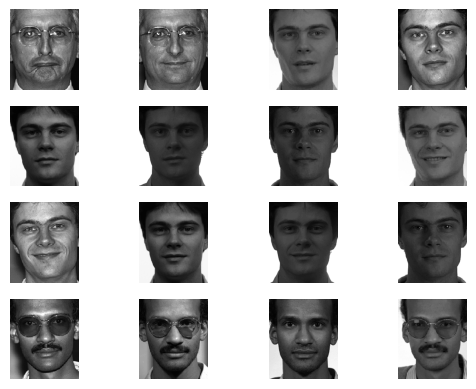

In [4]:
# Show some faces:
plt.figure()
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(faces[i], cmap=plt.cm.gray)
    plt.axis('off')
plt.show()

### Direct approach

1. Write a program that subsample the images (e.g. by 5), converts 2D images into lines, and collect all these lines into one single matrix **T**.
1. Zero-center **T** by removing the "mean image" ($T_i \leftarrow T_i - T_{mean}$)
1. Compute the variance/covariance matrix of **T**:
$$ \mathbf{S} = \mathbf{T^TT}$$
1. Compute the eigenvalues $\lambda_i$ and eigenvectors $\mathbf{v}_i$ of **S**
$$\mathbf{Sv}_i = \mathbf{T^T}\mathbf{Tv}_i = \lambda_i \mathbf{v}_i$$
1. The eigenvectors have the same size as the images, and are often referred to as "eigenfaces". Display some of them.

In [5]:
# Example of eigen value extraction
import numpy as np
from numpy import linalg as LA

w,v = LA.eig(np.diag((1, 2, 3)))
print(w,v)

[1. 2. 3.] [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


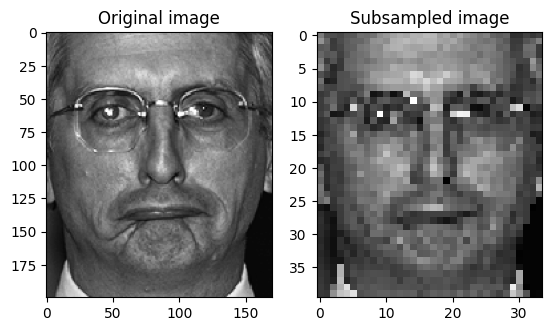

In [6]:
# Example of subsampling
im = faces[0]
plt.figure()
plt.subplot(1,2,1)
plt.imshow(im, cmap=plt.cm.gray)
plt.title("Original image")
plt.subplot(1,2,2)
plt.imshow(im[::5,::5], cmap=plt.cm.gray)
plt.title("Subsampled image")
plt.show()

/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1518632664.py:11: RuntimeWarning: divide by zero encountered in matmul
  S = T.T @ T                                    # (1360, 1360)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1518632664.py:11: RuntimeWarning: overflow encountered in matmul
  S = T.T @ T                                    # (1360, 1360)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1518632664.py:11: RuntimeWarning: invalid value encountered in matmul
  S = T.T @ T                                    # (1360, 1360)


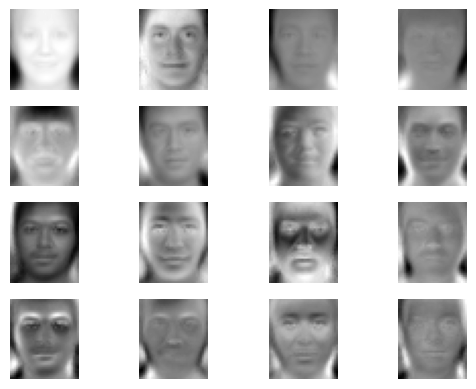

In [7]:
# 1. Subsample by 5 and turn each 2D image into a line -> matrix T
sub = faces[:, ::5, ::5]                       # (2963, 40, 34)
h, w = sub.shape[1], sub.shape[2]
T = sub.reshape(sub.shape[0], -1).astype(np.float64)   # (2963, 1360)

# 2. Zero-center: remove the mean image
mean_face = T.mean(axis=0)
T = T - mean_face

# 3. Covariance matrix S = T^T T
S = T.T @ T                                    # (1360, 1360)

# 4. Eigenvalues / eigenvectors (S is symmetric -> eigh), sorted by decreasing eigenvalue
eigvals, eigvecs = LA.eigh(S)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# 5. The eigenvectors have the size of an image -> display the first eigenfaces
plt.figure()
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(eigvecs[:, i].reshape(h, w), cmap=plt.cm.gray)
    plt.axis('off')
plt.show()

### Compression

1. Reconstruct images using only the first N eigenfaces (e.g. N=100).
2. Compare (visually) reconstructed images with original images

/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1174833510.py:4: RuntimeWarning: divide by zero encountered in matmul
  weights = T @ V                # project each centered image -> (2963, N)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1174833510.py:4: RuntimeWarning: overflow encountered in matmul
  weights = T @ V                # project each centered image -> (2963, N)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1174833510.py:4: RuntimeWarning: invalid value encountered in matmul
  weights = T @ V                # project each centered image -> (2963, N)
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1174833510.py:5: RuntimeWarning: divide by zero encountered in matmul
  recon = weights @ V.T + mean_face   # back to pixel space
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/1174833510.py:5: RuntimeWarning: overflow encountered in matmul
  recon = weights @ V.T + mean_face   # back to pi

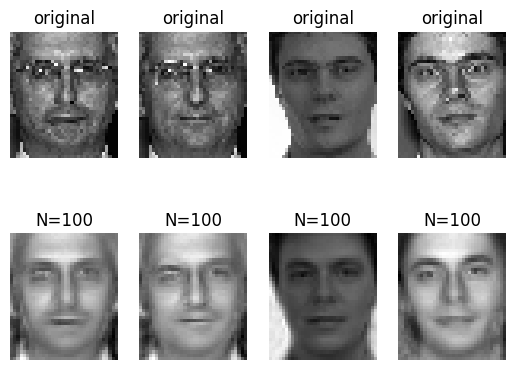

In [8]:
# Reconstruct images using only the first N eigenfaces
N = 100
V = eigvecs[:, :N]              # (1360, N) orthonormal basis
weights = T @ V                # project each centered image -> (2963, N)
recon = weights @ V.T + mean_face   # back to pixel space

# Compare original vs reconstructed
plt.figure()
for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow((T[i] + mean_face).reshape(h, w), cmap=plt.cm.gray)
    plt.axis('off'); plt.title("original")
    plt.subplot(2, 4, i + 5)
    plt.imshow(recon[i].reshape(h, w), cmap=plt.cm.gray)
    plt.axis('off'); plt.title("N=%d" % N)
plt.show()

### Face recognition

1. Using the simplified vector space (e.g. 100 first eigenfaces), compute the euclidian distance between one face and the others.
2. For a subset of the image of the database, find the 4 closest matches.

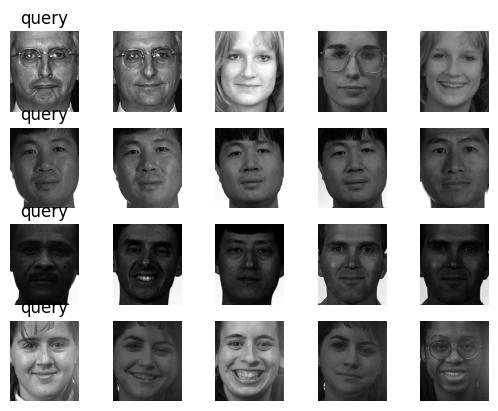

In [9]:
# Each face is now a point in the reduced (N=100) eigenface space
features = weights      # (2963, N)

def closest(i, k=4):
    dist = np.sqrt(((features - features[i]) ** 2).sum(axis=1))
    dist[i] = np.inf       # ignore the query itself
    return np.argsort(dist)[:k]

# For a subset of faces, show the 4 closest matches
queries = [0, 100, 500, 1000]
plt.figure()
for r, q in enumerate(queries):
    plt.subplot(len(queries), 5, r * 5 + 1)
    plt.imshow(faces[q], cmap=plt.cm.gray); plt.axis('off'); plt.title("query")
    for c, m in enumerate(closest(q, 4)):
        plt.subplot(len(queries), 5, r * 5 + 2 + c)
        plt.imshow(faces[m], cmap=plt.cm.gray); plt.axis('off')
plt.show()

### Indirect approach

Instead of using the eigenvalues/eigenvectors of $\mathbf{S} = \mathbf{T^TT}$, compute the the eigenvalues/eigenvectors of $\mathbf{Q} = \mathbf{TT^T}$.

Let $\mathbf{u_i}$ be the eigenvectors of $\mathbf{Q}$. We have:
$$\mathbf{TT^T}\mathbf{u}_i = \lambda_i \mathbf{u}_i$$

By multiplying to the left with $\mathbf{T^T}$, we have:
$$\mathbf{T^T}\mathbf{TT^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$
$$\mathbf{S}\mathbf{T^T}\mathbf{u}_i = \lambda_i\mathbf{T^T}\mathbf{u}_i$$

Which means that if $\mathbf{u}_i$ is eigenvector of $\mathbf{Q}$, then $\mathbf{T^T}\mathbf{u}_i$ is eigenvector of $\mathbf{S}$.

The indirect approach thus becomes:
1. Compute the eigenvectors $\mathbf{u}_i$ of $\mathbf{Q} = \mathbf{TT^T}$.
1. Compute the eigenfaces with $\mathbf{v}_i = \mathbf{T^T}\mathbf{u}_i$ 
1. Reconstruct the images using only the first N eigenfaces (e.g. N=100)
1. Compare (visually) reconstructed images with original images
1. Use the indirect approach with more resolution (without subsampling the images)

Use this new feature space to perform the same face recognition method.

/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:7: RuntimeWarning: divide by zero encountered in matmul
  Q = Tf @ Tf.T
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:7: RuntimeWarning: overflow encountered in matmul
  Q = Tf @ Tf.T
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:7: RuntimeWarning: invalid value encountered in matmul
  Q = Tf @ Tf.T
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:13: RuntimeWarning: divide by zero encountered in matmul
  Vf = Tf.T @ U
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:13: RuntimeWarning: overflow encountered in matmul
  Vf = Tf.T @ U
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:13: RuntimeWarning: invalid value encountered in matmul
  Vf = Tf.T @ U
/var/folders/3v/7qmm1wrn4svcfm1hdpf_22lw0000gn/T/ipykernel_25354/854811585.py:19: RuntimeWarning: divide by zer

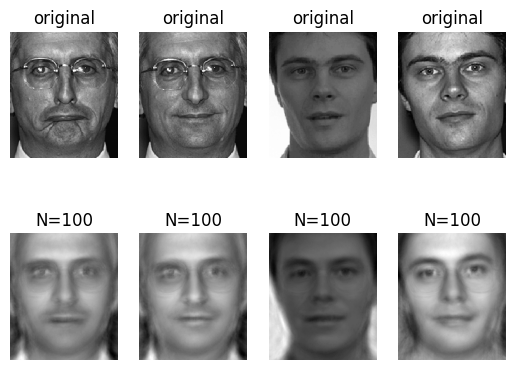

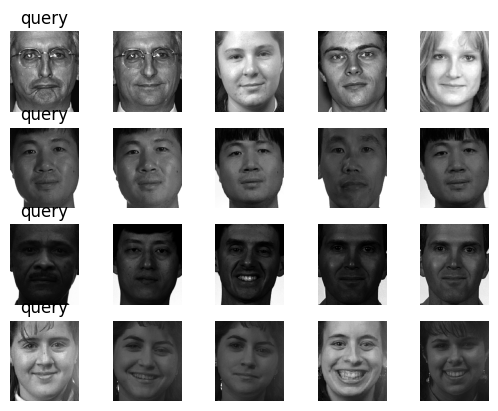

In [10]:
# Indirect approach, at full resolution (no subsampling)
Tf = faces.reshape(faces.shape[0], -1).astype(np.float64)   # (2963, 34000)
mean_full = Tf.mean(axis=0)
Tf = Tf - mean_full

# 1. Eigenvectors u_i of Q = T T^T  (2963 x 2963 instead of 34000 x 34000)
Q = Tf @ Tf.T
eigvals_q, U = LA.eigh(Q)
order = np.argsort(eigvals_q)[::-1]
U = U[:, order]

# 2. Eigenfaces v_i = T^T u_i  (then normalized to unit norm)
Vf = Tf.T @ U
Vf = Vf / np.linalg.norm(Vf, axis=0)

# 3. Reconstruct with the first N eigenfaces
N = 100
Vfn = Vf[:, :N]
weights_full = Tf @ Vfn
recon_full = weights_full @ Vfn.T + mean_full

# 4. Compare original vs reconstructed (full resolution)
H, W = faces.shape[1], faces.shape[2]
plt.figure()
for i in range(4):
    plt.subplot(2, 4, i + 1)
    plt.imshow(faces[i], cmap=plt.cm.gray); plt.axis('off'); plt.title("original")
    plt.subplot(2, 4, i + 5)
    plt.imshow(recon_full[i].reshape(H, W), cmap=plt.cm.gray); plt.axis('off'); plt.title("N=%d" % N)
plt.show()

# 5. Same face recognition method in this new (full-resolution) feature space
features_full = weights_full

def closest_full(i, k=4):
    dist = np.sqrt(((features_full - features_full[i]) ** 2).sum(axis=1))
    dist[i] = np.inf
    return np.argsort(dist)[:k]

queries = [0, 100, 500, 1000]
plt.figure()
for r, q in enumerate(queries):
    plt.subplot(len(queries), 5, r * 5 + 1)
    plt.imshow(faces[q], cmap=plt.cm.gray); plt.axis('off'); plt.title("query")
    for c, m in enumerate(closest_full(q, 4)):
        plt.subplot(len(queries), 5, r * 5 + 2 + c)
        plt.imshow(faces[m], cmap=plt.cm.gray); plt.axis('off')
plt.show()